In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib.collections import PolyCollection
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker

plt.rcParams['figure.figsize'] = [10, 6]

# Calibration + Conversion (from CoolNewton_Data.ipynb)

## Calibration Values

In [2]:
Troom = 20.2 # water taken from the tap
Vroom = np.array([-0.07552724, -0.08564685, -0.07672076, -0.08612363, -0.10711619, -0.1078814,
 -0.08697812, -0.1078605,  -0.10617525, -0.11628798, -0.09717631, -0.11676893,
 -0.09690153, -0.0976667,  -0.08697812, -0.1078605 ])

In [3]:
Thot = 76.5 # initial hot water temperature (from boiled kettle)
Vhot = np.array([1.68162501, 1.66089737, 1.69268489, 1.68108879, 1.67023401,1.66947625,
 1.68046395, 1.66964336, 1.630545,   1.64046995, 1.641546,   1.64022838,
 1.68044866, 1.67969095, 1.68046395, 1.69007444])

# all subsequent Thot(n) values are of the cooling hot water, about 10C between

In [4]:
Thot1 = 66.3
Vhot1 = np.array([1.37514497, 1.36469981, 1.37562376, 1.38485087, 1.38422363, 1.36303528,
 1.39440396, 1.36317718, 1.34449696, 1.34427239, 1.35516821, 1.33377536,
 1.38422363, 1.38346468, 1.39440396, 1.3938238 ])

In [5]:
Thot2 = 56.3
Vhot2 = np.array([1.04823292, 1.02764742, 1.05856264, 1.03753745, 1.03692532, 1.02595021,
 1.05726183, 1.03627992, 1.02780092, 1.01743371, 1.0278793,  1.01710724,
 1.03692532, 1.0361649,  1.05726183, 1.04649546])

In [6]:
Thot3 = 45.8
Vhot3 = np.array([0.70088887, 0.69059502, 0.71081817, 0.70043912, 0.67941234, 0.67865043,
 0.70990328, 0.68895158, 0.67024086, 0.6599539,  0.68013484, 0.66979382,
 0.69984166, 0.69907983, 0.70990328, 0.70938266])

In [7]:
Thot4 = 36.5
Vhot4 = np.array([0.40462483, 0.40461117, 0.42444038, 0.41441631, 0.38318731, 0.38242416,
 0.41362686, 0.39270094, 0.38419282, 0.37397005, 0.38352927, 0.3735559,
 0.39340197, 0.39263886, 0.41362686, 0.39270094])

In [8]:
Thot5 = 26.7 # about room temperature, achieved quicker by adding ice/cold water and stirring
Vhot5 = np.array([0.07771278, 0.06755878, 0.07669592, 0.07731798, 0.04610365, 0.04533909,
 0.06626831, 0.0453726,  0.04706477, 0.03691765, 0.05624036, 0.03645758,
 0.06653297, 0.06576849, 0.08670116, 0.06580368])

## Calibration

In [100]:
temps=np.array([Troom, Thot, Thot1, Thot2, Thot3, Thot4, Thot5])
volts=np.stack([Vroom, Vhot, Vhot1, Vhot2, Vhot3, Vhot4, Vhot5]) # need to stack the (7,16) matrices

Terr=1 # thermometer uncertainty from spec sheet

def linearfit(m,x,c):
    return m*x+c

slopes=np.zeros(16)
intercs=np.zeros(16)
slopes_err=np.zeros(16)
intercs_err=np.zeros(16)
mccov_TC=np.zeros(16)

for i in range(16):
    vs=volts[:,i]
    popt, pcov = curve_fit(linearfit, vs, temps, sigma=np.full_like(temps, Terr), absolute_sigma=True)
    slopes[i], intercs[i]=popt
    slopes_err[i], intercs_err[i]=np.sqrt(np.diag(pcov))
    mccov_TC[i]=pcov[0,1]

In [108]:
def calib_plot(volts, temps, slopes, intercs, vzoom=None, tzoom=None, temperr=1, volterr=0.005):

    colors=plt.cm.jet_r(np.linspace(0,1,16))

    for i in range(16):
        vs=volts[:,i]

        plt.errorbar(vs,temps,yerr=temperr,xerr=volterr,fmt='o',color=colors[i],markersize=5,alpha=0.7,capsize=5)

        vline=np.linspace(volts.min(),volts.max(),50)
        tline=slopes[i]*vline+intercs[i]
        plt.plot(vline,tline,'-',color=colors[i],label=f'TCouple {i+1}',alpha=0.7)

    plt.xlabel('Raw Voltage (V)')
    plt.ylabel('Reference Temperatures (C)')
    plt.grid(True, linestyle='--', alpha=0.4)

    plt.legend(ncol=2, framealpha=0.5, loc='upper left')

    if vzoom is not None:
        plt.xlim(vzoom)
    if tzoom is not None:
        plt.ylim(tzoom)

    plt.tight_layout()
    plt.show()

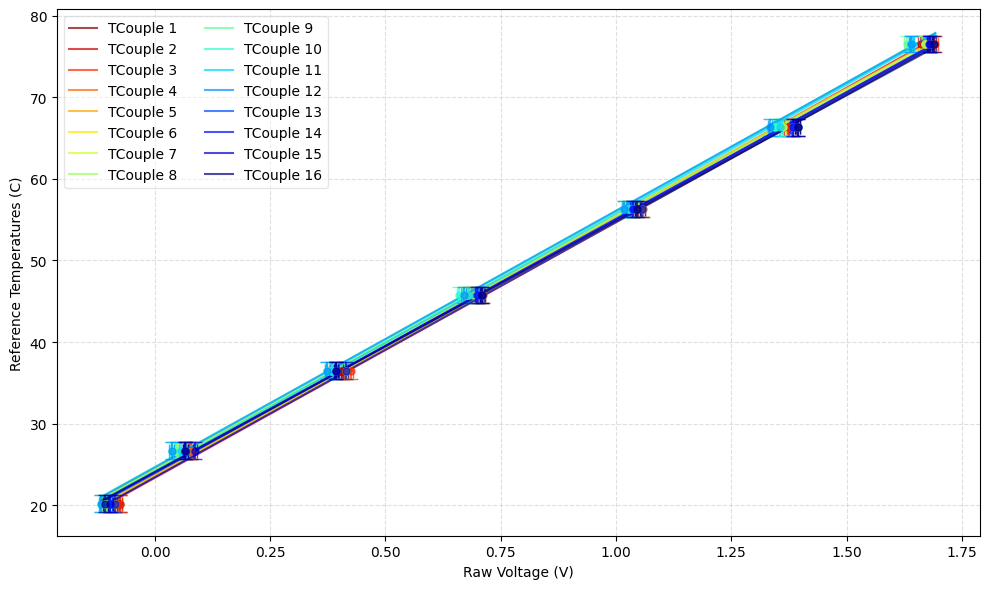

In [109]:
calib_plot(volts, temps, slopes, intercs, vzoom=None, tzoom=None, temperr=1, volterr=0.005)

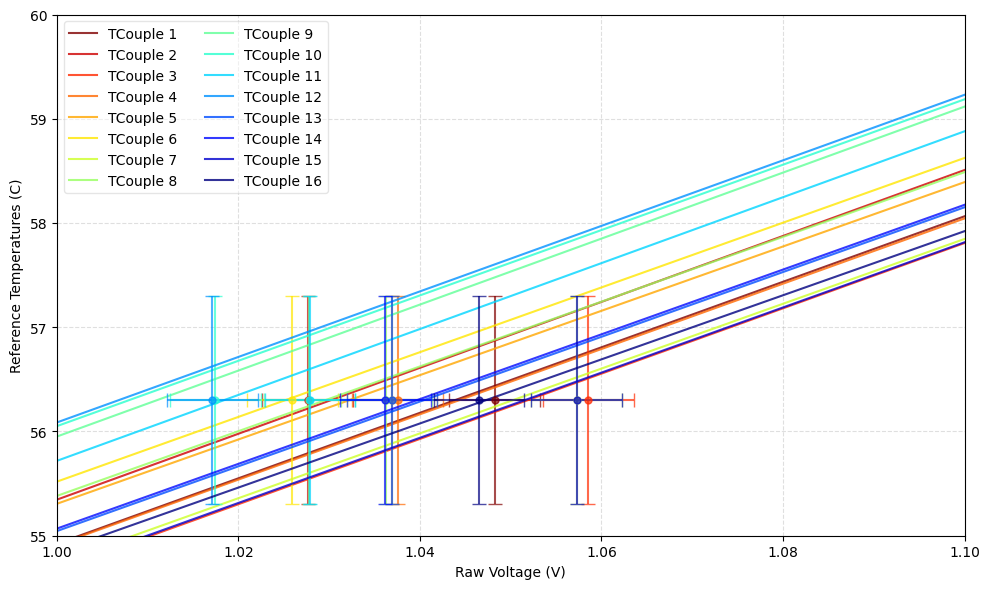

In [103]:
calib_plot(volts, temps, slopes, intercs, vzoom=(1,1.1), tzoom=(55,60), temperr=1, volterr=0.005)

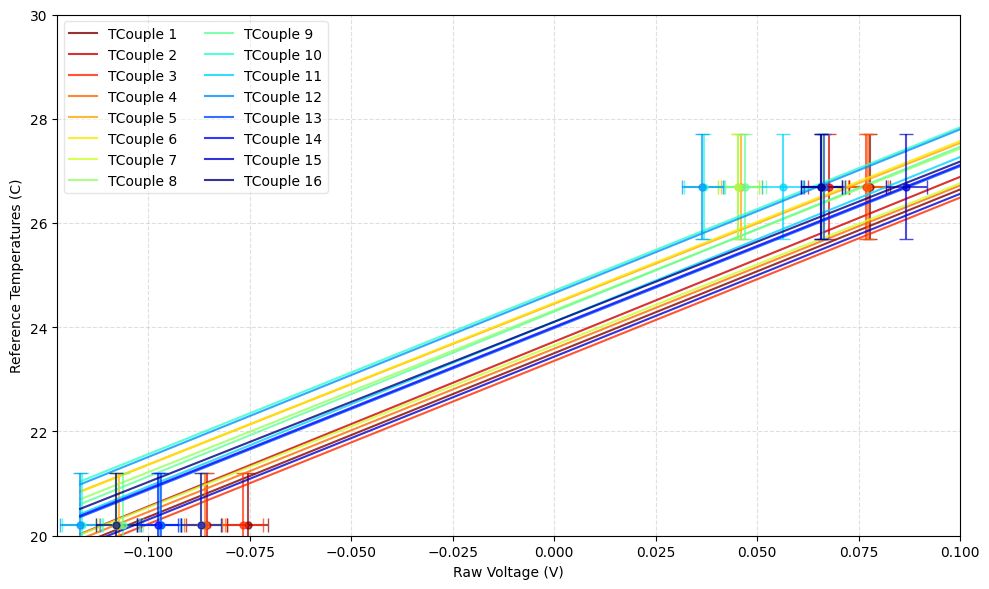

In [99]:
calib_plot(volts, temps, slopes, intercs, vzoom=(-0.1225,0.1), tzoom=(20,30), temperr=1, volterr=0.005)

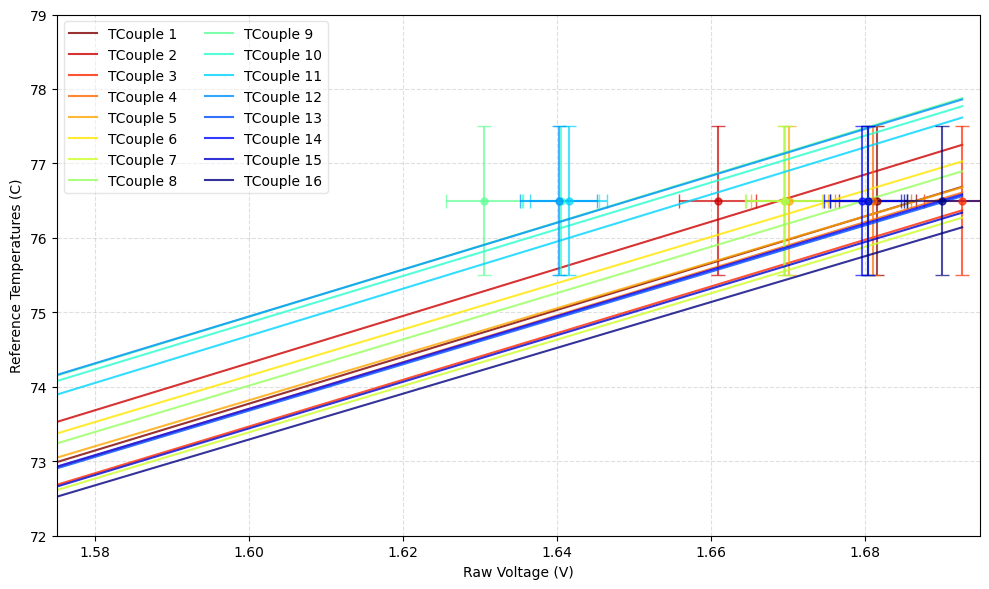

In [94]:
calib_plot(volts, temps, slopes, intercs, vzoom=(1.575,1.695), tzoom=(72,79))

### Conversion

In [15]:
def volt_to_C(v):
    temp_C=(v*slopes)+intercs
    return temp_C

def volt_to_K(v):
    temp_C=(v*slopes)+intercs
    return temp_C + 273.15

In [16]:
# error propagation for the calibrationg gave a pcov matrix, in which the diagonal elements are the variances of the slope and intercept, and the off-diagonal elements are the covariances between slope and intercept (all need to be considered) 
# the error propagation formula for a linear function y = mx + c is given by:
# sigma^2_T = V^2 * sigma^2_m + sigma^2_c + 2*V*sigma_mc + m^2 * sigma^2_V
# sigma_mc is the covariance between slope and intercept, and it's the same in the off-diagonal, hence *2

def volt_to_C_err(v, v_err=0.0):
    temp_C=(v*slopes)+intercs
    errprop_T=(v**2)*(slopes_err**2)+(intercs_err**2) + 2*v*mccov_TC+(slopes**2)*(v_err**2)
    return temp_C, np.sqrt(errprop_T)

def volt_to_K_err(v, v_err=0.0):
    temp_C, err_T=volt_to_C_err(v, v_err)
    return temp_C+273.15, err_T

# Analysis

## Conversion

In [17]:
tc_z=0.05 # (m)
n = 16

terr=1
zerr=0.005

In [18]:
def load_run(filename, interval_sec=60, v_err=0.0):
    data=pd.read_csv(filename)
    V=data.values
    t_C=np.round(volt_to_C(V), 2)
    t_K=np.round(volt_to_K(V), 2)
    _, t_Cerr=volt_to_C_err(V, v_err)
    t_Cerr=np.round(t_Cerr, 2)
    t_mins=np.arange(75) * (interval_sec / 60)

    tcouple_col=[f'TCouple {i+1}' for i in range(n)]

    df_C=pd.DataFrame(t_C, columns=tcouple_col, index=t_mins)
    df_K=pd.DataFrame(t_K, columns=tcouple_col, index=t_mins)
    df_Cerr=pd.DataFrame(t_Cerr,columns=tcouple_col, index=t_mins)

    df=pd.concat([df_C, df_K, df_Cerr], axis=1, keys=['°C', 'K', 'σ(°C)'])
    df.index.name='Time (mins)'

    return df

In [19]:
uni_df=load_run('/Users/JoanaUCD/Library/CloudStorage/OneDrive-UniversityCollegeDublin/Labs/labs-files/labs_code/Labs-Code/labcode_s4/uniform_run.csv')
print(uni_df)
uni_df.to_csv('Uniform Run Data.csv')

                   °C                                                    \
            TCouple 1 TCouple 2 TCouple 3 TCouple 4 TCouple 5 TCouple 6   
Time (mins)                                                               
0.0             32.05     32.01     31.68     31.70     30.24     30.41   
1.0             32.05     32.01     31.92     31.46     30.24     30.16   
2.0             32.29     32.26     31.92     31.70     29.99     30.16   
3.0             32.77     32.50     32.16     31.94     29.99     29.91   
4.0             33.49     32.98     32.63     32.18     29.99     29.91   
...               ...       ...       ...       ...       ...       ...   
70.0           105.76     98.16     91.16     86.88     59.71     48.91   
71.0           105.76     98.41     91.40     87.12     59.96     48.91   
72.0           105.76     98.41     91.40     87.12     59.96     48.91   
73.0           105.52     98.16     91.40     86.88     59.71     48.91   
74.0           105.76    

In [110]:
nonuni_df=load_run('/Users/JoanaUCD/Library/CloudStorage/OneDrive-UniversityCollegeDublin/Labs/labs-files/labs_code/Labs-Code/labcode_s4/nonuniform_run.csv')
print(nonuni_df)
uni_df.to_csv('Non-Uniform Run Data.csv')

                   °C                                                    \
            TCouple 1 TCouple 2 TCouple 3 TCouple 4 TCouple 5 TCouple 6   
Time (mins)                                                               
0.0             33.33     32.64     32.16     31.77     38.16     44.91   
1.0             33.97     33.29     33.13     33.05     36.90     40.15   
2.0             34.93     34.26     34.09     34.01     35.64     36.98   
3.0             36.22     35.23     34.73     34.65     34.38     35.07   
4.0             37.50     36.20     35.69     34.97     33.44     33.49   
...               ...       ...       ...       ...       ...       ...   
70.0           125.13    115.00    106.80     99.60     61.80     47.76   
71.0           125.13    115.00    106.80     99.60     62.12     47.76   
72.0           125.13    114.68    106.80     99.60     61.80     47.76   
73.0           125.13    115.00    106.48     99.60     61.80     47.76   
74.0           125.13    

## Effective Oven Temp

In [ ]:
# have [T(z)-T_R] = (T_L-T_R) * exp(-beta * z) from the papers
# take natural log of both sides to get ln([T(z)-T_R]) = ln(T_L-T_R) - beta * z and plot

T_SS_uni=uni_df['°C'].iloc[-1] # steady state temperature for uniform run
z_pos=np.linspace(0.05, 0.8, 16)
yuni_semilog=np.log(T_SS_uni - Troom)
unislope, uniinterc=np.polyfit(z_pos,yuni_semilog,1)
unibeta=-unislope
T_L_uni=Troom+np.exp(uniinterc)

T_SS_nonuni=nonuni_df['°C'].iloc[-1] # steady state temperature for non-uniform run
ynonuni_semilog=np.log(T_SS_nonuni - Troom)
nonunislope, nonuniinterc=np.polyfit(z_pos,ynonuni_semilog,1)
nonunibeta=-nonunislope
T_L_nonuni=Troom+np.exp(nonuniinterc)

In [22]:
errT_uni=uni_df['σ(°C)'].iloc[-1]
errlnT_uni=errT_uni/(T_SS_uni-Troom)

print(f'Uniform run beta = {unibeta:.4f} 1/m')
print(f'Uniform run T_L = {T_L_uni:.2f} C')

errT_nonuni=nonuni_df['σ(°C)'].iloc[-1]
errlnT_nonuni=errT_nonuni/(T_SS_nonuni-Troom)

print(f'Non-uniform run beta = {nonunibeta:.4f} 1/m')
print(f'Non-uniform run T_L = {T_L_nonuni:.2f} C')

Uniform run beta = 2.7458 1/m
Uniform run T_L = 113.99 C
Non-uniform run beta = 2.7656 1/m
Non-uniform run T_L = 116.39 C


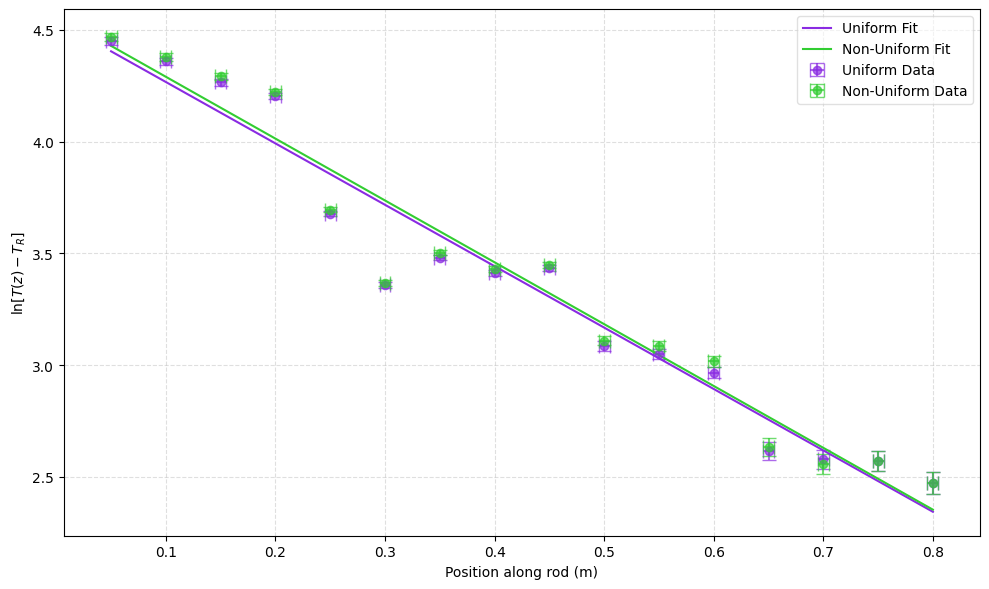

In [23]:
fig, ax=plt.subplots(figsize=(10,6))

ax.errorbar(z_pos, yuni_semilog, xerr=zerr, yerr=errlnT_uni , fmt='o',label='Uniform Data', color='blueviolet',alpha=0.7,capsize=5)
ax.errorbar(z_pos, ynonuni_semilog, xerr=zerr, yerr=errlnT_nonuni, fmt='o',label='Non-Uniform Data', color='limegreen',alpha=0.7,capsize=5)
zcont=np.linspace(0.05,0.8,50)

ax.plot(zcont, (unislope*zcont+uniinterc), '-', label='Uniform Fit', color='blueviolet')
ax.plot(zcont, (nonunislope*zcont+nonuniinterc), '-', label='Non-Uniform Fit', color='limegreen')
ax.set_xlabel('Position along rod (m)')
ax.set_ylabel(r'$\ln[T(z)-T_R]$')

ax.legend(framealpha=0.6)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [114]:
def explogpart(z,beta,lnA):
    return -beta*z + lnA

popt_uni, pcov_uni = curve_fit(explogpart,z_pos,yuni_semilog, sigma=errlnT_uni, absolute_sigma=True)
unibeta_w, uniinterc_w =popt_uni # slope gives beta value
unc_unibeta, unc_uniinterc =np.sqrt(np.diag(pcov_uni))
unc_uniTL = np.exp(uniinterc_w) * unc_uniinterc # error propagation from T_L = T_R + exp(lnA)

popt_nonuni, pcov_nonuni = curve_fit(explogpart, z_pos,ynonuni_semilog, sigma=errlnT_nonuni, absolute_sigma=True)
nonunibeta_w, nonuniinterc_w =popt_nonuni
unc_nonunibeta, unc_nonuniinterc=np.sqrt(np.diag(pcov_nonuni))
unc_nonuniTL=np.exp(nonuniinterc_w) * unc_nonuniinterc

print(f'UNIFORM:\nbeta= {unibeta_w:.4f} ± {unc_unibeta:.4f} 1/m\nT_L= {Troom+np.exp(uniinterc_w):.2f} ± {unc_uniTL:.2f} C\n')
print(f'NON-UNIFORM:\nbeta= {nonunibeta_w:.4f} ± {unc_nonunibeta:.4f} 1/m\nT_L= {Troom+np.exp(nonuniinterc_w):.2f} ± {unc_nonuniTL:.2f} C\n')

UNIFORM:
beta= 2.8216 ± 0.0264 1/m
T_L= 113.99 ± 0.88 C

NON-UNIFORM:
beta= 2.8042 ± 0.0261 1/m
T_L= 115.21 ± 0.90 C



## Steady-State Profile

In [76]:
def waterfallplot_3d(t, z, T, ax=None, baseline=None, facecolor='white', edgecolor='black', xlabel='t (mins)', ylabel='Z (cm)', zlabel='T (°C)', title=None, figsize=(7,5)):

    # t: shape(nt, )
    # z: shape(nz, )
    # T: shape(nt, nz)

    t = np.asarray(t); z = np.asarray(z); T = np.asarray(T) # np.asarray used as it treats as an array without converting unless necessary
    assert T.shape == (len(t), len(z)) # ie, checks that T has this shape (nt, nz)

    if ax is None: # making a 3d plot if one hadn't been previously defined, just in case
        fig = plt.figure(figsize=figsize)
        ax = fig.add_suplot(111, projection='3d') # (1,1,1) is default, in place of (nrows, ncols, index)

    if baseline is None: # calculating the lowest point (bottom edge)
        baseline=T.min() - 0.05 * (T.max()-T.min()) # takes lowest and subracts 5% of total range to make the graph look neater

    order=np.argsort(-z) # make it look better with the large z first and small z last (ie, in order of closeness to oven)
    for j in order:
        curve= T[:,j]
        _2dpart=[(t[0],baseline)] + list(zip(t,curve)) + [(t[-1],baseline)] # bottomleft corner, data (paired time t and temp curve T), bottom right corner

        cmap=plt.get_cmap('jet_r')
        norm=mcolors.Normalize(vmin=z.min(),vmax=z.max())
        colors=cmap(norm(z[j]))
        
        poly= PolyCollection([_2dpart], facecolor=colors, edgecolor=edgecolor, alpha=0.8) # turns the corners into a 2d shape
        ax.add_collection3d(poly, zs=z[j], zdir='y') # turns into 3d shape, with y-axis as the depth axis

    ax.set_xlim(t.min(), t.max())
    ax.set_ylim(z.min(), z.max())
    ax.set_zlim(baseline, T.max() * 1.02) # going 2% above limit to make it neater

    ax.set_xlabel(xlabel, labelpad=5)
    ax.set_ylabel(ylabel,labelpad=5)
    ax.set_zlabel(zlabel,labelpad=5)
    if title:
        ax.set_title(title, y=0.96)

    ax.view_init(elev=25, azim=-65) # aesthetics (change elevation and azimuthal to where we are "looking")
    ax.invert_yaxis() # z=0 (near source) put at back

    ax.xaxis.pane.set_alpha(0); ax.yaxis.pane.set_alpha(0); ax.yaxis.pane.set_alpha(0) # background (0-1 value, 0=transparent)
    ax.grid(False)

    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator(2))

    return ax

def waterfall_df(df,z,unit='°C', **kwargs): # **kwargs just copies any style change
    t=df.index.values
    T=df[unit].values

    return waterfallplot_3d(t,z,T,**kwargs)


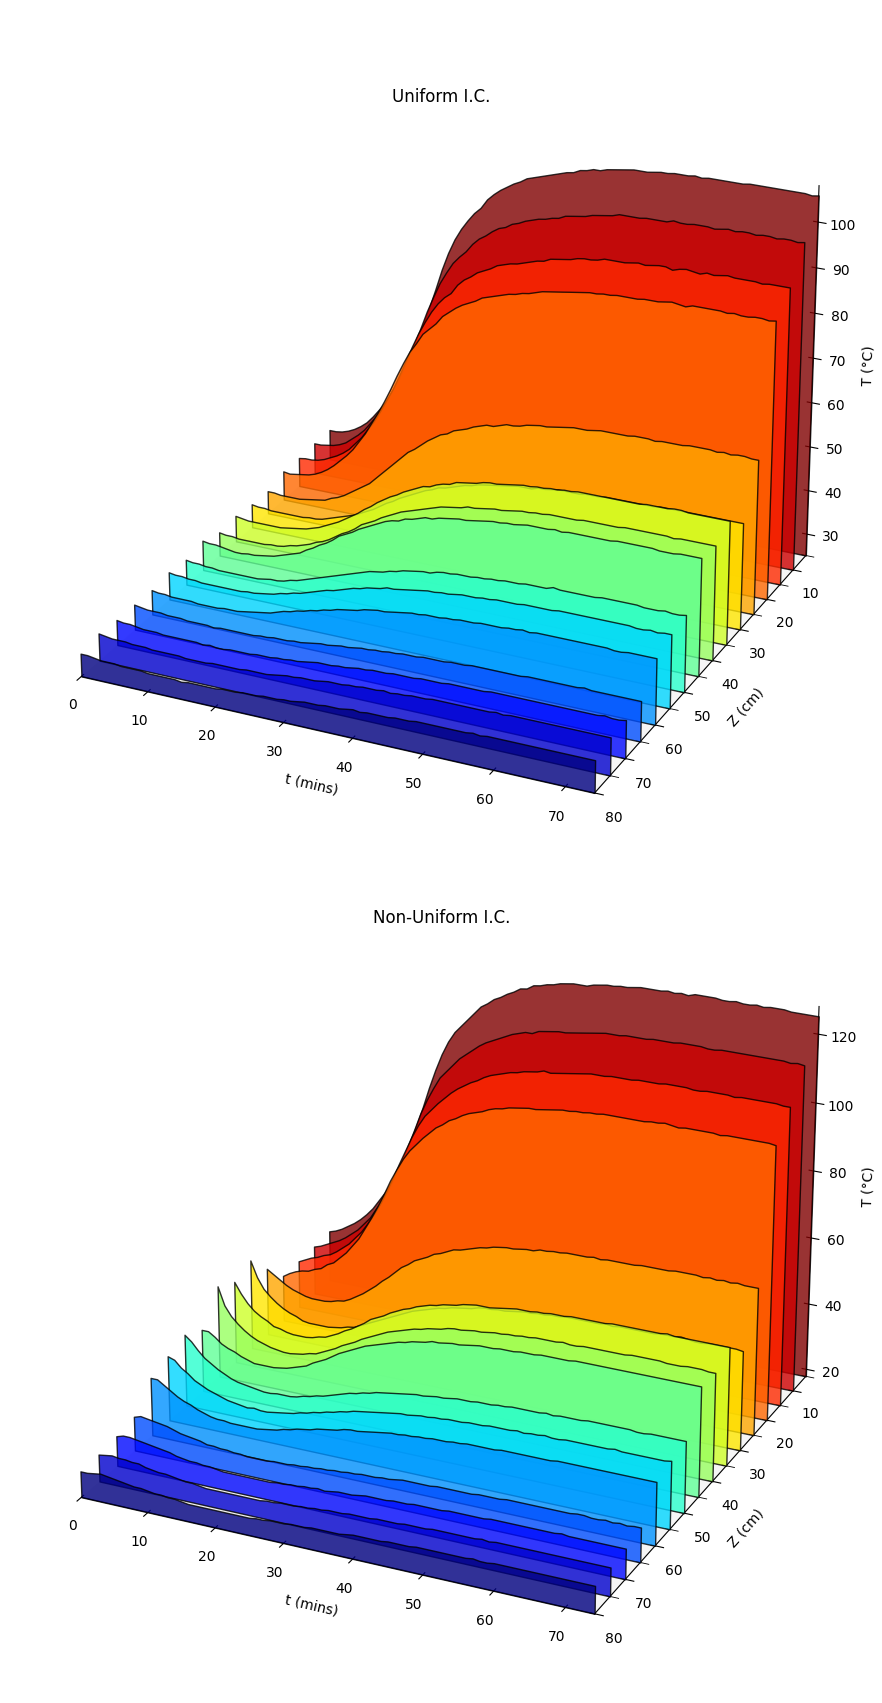

In [121]:
fig=plt.figure(figsize=(8,16))

ax1 = fig.add_subplot(211, projection='3d')
waterfall_df(uni_df, z_pos*1e2, ax=ax1, title='Uniform I.C.')

ax2= fig.add_subplot(212, projection='3d')
waterfall_df(nonuni_df, z_pos*1e2, ax=ax2, title='Non-Uniform I.C.')

plt.tight_layout(pad=-3)
plt.show()

## Entropy Production

### $\frac{d_eS}{dt} \propto \int^L_0 \frac{1}{T}\left( \frac{\partial^2T}{\partial z^2} \right) dz - \int^L_0 \frac{1}{T^2} \left( \frac{\partial T}{\partial z} \right)^2 dz - \frac{2H}{\lambda r} \int^L_0 \frac{1}{T} (T-T_R)dz$
this is the term which derives from the transfer of heat across the boundary of the system

### $\frac{d_i S}{dt} \propto \int^L_0 \frac{1}{T^2} \left( \frac{\partial T}{\partial z} \right)^2 dz$
this is the term due to exchanges inside the system

both of these expressions use only terms experimentally accessible
these then give (which can be plotted and computed) for each thermocouple:

### $\frac{d_eS}{dt} \propto -\frac{1}{l} \frac{1}{T_0} (T_1-T_0) + \frac{1}{l}\frac{1}{T_n} (T_n - T_{n-1}) - \beta^2 l \sum^{n-1}_{i=1} \left(1-\frac{T_n}{T_i}\right)$

and

### $\frac{d_i S}{dt} \propto -\frac{1}{l} \sum^{n-1}_{i=0} (T_{i+1} - t_i) \left( \frac{1}{T_{i+1}} - \frac{1}{T_i} \right)$

in this case, T is in Kelvin and the entropy will always be greater than or equal to 0 (as per thermodynamic law) and $dS/dt = d_iS/dt + d_eS/dt$ as the total entropy of the system exchanged with the surroundings

In [56]:
def entropies(T_K, T0, Tn, l, beta, tol=0.01, max_extra=2000):
    # T0 = boundary temp (furnace)
    # Tn = ambient bath temp

    nTC, m = T_K.shape # for the 16 thermocouples
    T0=np.broadcast_to(T0,(nTC,)).astype(float) # stretches a single value to match a specific shape w/o duplicating it

    z_lastTC = m * l # where the last thermocouple is (calculated)
    dT0 = float(np.mean(T0))-Tn # finding average temp above ambient (difference)

    n_extra = 0
    z=z_lastTC
    while dT0 * np.exp(-beta * z) > tol and n_extra < max_extra: # extend steps z by length l until temp decay satisfied
        n_extra +=1
        z +=l # this moving them
    z_extra=z_lastTC +l *np.arange(1,n_extra+1)
    T_extra=Tn+dT0 *np.exp(-beta * z_extra) # virtual points calculations
    T_extra=np.tile(T_extra, (nTC,1)) # evaluating the same things for all the virtual points

    T_tot = np.column_stack([T0, T_K, T_extra, np.full(nTC, Tn)]) # makes a (nt, m+n_extra+2) shape (ie "gluing" the thermocouple columns together to make a singular array)

    dT = np.diff(T_tot, axis=1) # subtracts each column from the subsequent one (temp difference between each thermocouple at each taken measurement)
    dinvT = np.diff(1/T_tot, axis=1) # same but for inverse temp

    diS_dt = -(1/l) * np.sum(dT * dinvT, axis=1)

    deS_dt = (-(1/l) * (1/T_tot[:,0]) * (T_tot[:,1] - T_tot[:,0]) # entropy in
              + (1/l) * (1/T_tot[:,-1]) * (T_tot[:,-1] - T_tot[:,-2]) # entropy out
              - beta**2 * l * np.sum(1- Tn/T_tot[:, 1:-1], axis=1)) # entropy lost

    return diS_dt, deS_dt

In [ ]:
T0_uni = T_L_uni + 273.15
T0_nonuni = T_L_nonuni + 273.15
Tn = Troom + 273.15

diS_uni, deS_uni = entropies(uni_df['K'].values, T0_uni, Tn, tc_z, unibeta)
dS_uni = diS_uni + deS_uni

diS_nonuni, deS_nonuni = entropies(nonuni_df['K'].values, T0_nonuni, Tn, tc_z, nonunibeta)
dS_nonuni = diS_nonuni + deS_nonuni

print(f'Uniform:\ndiS/dt= {diS_uni[0]:.4f} --> {diS_uni[-1]:.4f}\n')
print(f'Uniform:\ndeS/dt= {deS_uni[0]:.4f} --> {deS_uni[-1]:.4f}\n')
print(f'Non-uniform:\ndiS/dt= {diS_nonuni[0]:.4f} --> {diS_nonuni[-1]:.4f}\n')
print(f'Non-uniform:\ndiS/dt= {deS_nonuni[0]:.4f} --> {deS_nonuni[-1]:.4f}\n')
print(f'Second thermodynamic law check:\nuniform= {np.all(deS_uni >= 0)}\nnon-uniform= {np.all(diS_nonuni >= 0)}') # just checking if theyre greater than or equal to 0

Uniform:
diS/dt= 1.1395 --> 0.2047

Uniform:
deS/dt= 3.9282 --> -0.2992

Non-uniform:
diS/dt= 1.2125 --> 0.3581

Non-uniform:
diS/dt= 3.8876 --> -1.1890

Second thermodynamic law check:
uniform= True
non-uniform= True


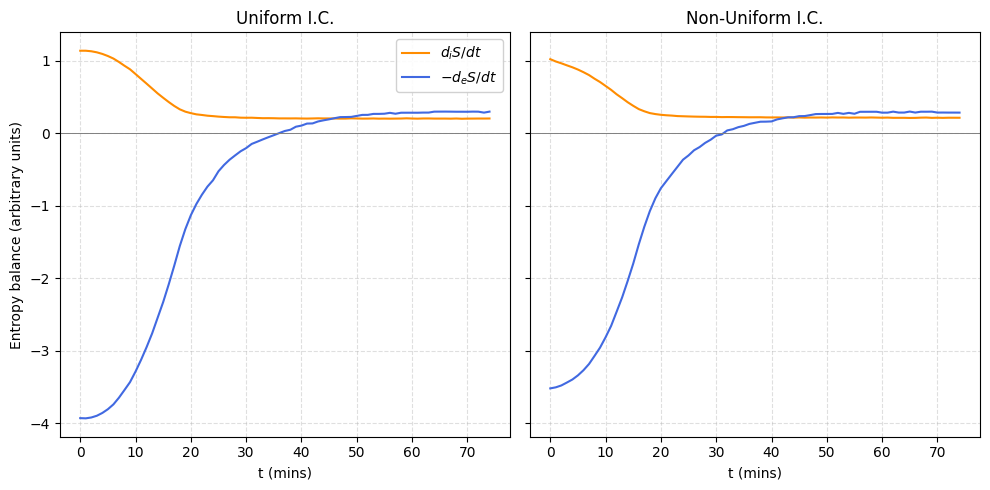

In [113]:
fig, axes=plt.subplots(1,2,figsize=(10,5), sharey=True)

for ax, t, diS, deS, dS, label in [
    (axes[0], uni_df.index.values, diS_uni, -deS_uni, dS_uni, 'Uniform I.C.'),
    (axes[1], nonuni_df.index.values, diS_nonuni, -deS_nonuni, dS_uni, 'Non-Uniform I.C.')
]:
    ax.plot(t, diS, '-', color='darkorange', label=r'$d_iS/dt$')
    ax.plot(t, deS, '-', color='royalblue', label=r'$-d_eS/dt$')
    ax.axhline(0, color='grey', lw=0.7)
    ax.set_xlabel('t (mins)')
    ax.set_title(label)
    ax.grid(True, linestyle='--', alpha=0.4)

axes[0].set_ylabel('Entropy balance (arbitrary units)')
axes[0].legend(framealpha=0.9)

plt.tight_layout()
plt.show()

In [59]:
# using monte carlo error propagation because otherwise too complicated and long to do the calc
# actually thinking of all that math and figuring out the analytical error propagation makes me sick
# monte carlo also follows a gaussian curve of errors, which works fine because we already calculated the uncertainties on individual measurements

def entropy_mcunc(df, TL, unc_TL, Troom, Terr, l, beta, unc_beta, n_trials=500, seed=0):
    rng = np.random.default_rng(seed)
    T_meas=df['°C'].values
    unc_T=df['σ(°C)'].values
    nTC, m =T_meas.shape

    diS_trials=np.empty((n_trials,nTC)) # empty arrays with this shape
    deS_trials=np.empty((n_trials,nTC))

    for k in range(n_trials):
        T_sample_K=(T_meas +rng.normal(0,unc_T)) +273.15 # takes the experimental data and adds random noise based on the measured uncertainty and converts to K
        T0_K=rng.normal(TL, unc_TL) +273.15
        Tn_K=rng.normal(Troom, Terr) +273.15
        beta_K=rng.normal(beta, unc_beta)
        diS_K, deS_K=entropies(T_sample_K, T0_K, Tn_K, l, beta_K) # gets the curves for each individual version in which random noise was added
        diS_trials[k]=diS_K
        deS_trials[k]=deS_K

    return diS_trials.mean(axis=0), diS_trials.std(axis=0), deS_trials.mean(axis=0), deS_trials.std(axis=0) # mean = 'true' curve, std = standard deviation

In [ ]:
diS_uni_min, diS_uni_std, deS_uni_min, deS_uni_std = entropy_mcunc(uni_df, T_L_uni, unc_uniTL, Troom, Terr, tc_z, unibeta_w, unc_unibeta)

diS_nonuni_min, diS_nonuni_std, deS_nonuni_min, deS_nonuni_std= entropy_mcunc(nonuni_df, T_L_nonuni, unc_nonuniTL, Troom, Terr, tc_z, nonunibeta_w, unc_nonunibeta)

print('Uniform I.C.')
print(f'd_iS/dt at t=0 (min): {diS_uni_min[0]:.4g} ± {diS_uni_std[0]:.4g}\nd_iS/dt at steady state: {diS_uni_min[-1]:.4g} ± {diS_uni_std[-1]:.4g}')
print(f'd_eS/dt at t=0 (min): {deS_uni_min[0]:.4g} ± {deS_uni_std[0]:.4g}\nd_eS/dt at steady state: {deS_uni_min[-1]:.4g} ± {deS_uni_std[-1]:.4g}\n')

print('Non-Uniform I.C.')
print(f'd_iS/dt at t=0 (min): {diS_nonuni_min[0]:.4g} ± {diS_nonuni_std[0]:.4g}\nd_iS/dt at steady state: {diS_nonuni_min[-1]:.4g} ± {diS_nonuni_std[-1]:.4g}')
print(f'd_eS/dt at t=0 (min): {deS_nonuni_min[0]:.4g} ± {deS_nonuni_std[0]:.4g}\nd_eS/dt at steady state: {deS_nonuni_min[-1]:.4g} ± {deS_nonuni_std[-1]:.4g}\n')

Uniform I.C.
d_iS/dt at t=0 (min): 1.142 ± 0.03161
d_iS/dt at steady state: 0.2086 ± 0.009139
d_eS/dt at t=0 (min): 3.919 ± 0.05582
d_eS/dt at steady state: -0.3329 ± 0.09272

Non-Uniform I.C.
d_iS/dt at t=0 (min): 1.025 ± 0.02708
d_iS/dt at steady state: 0.2186 ± 0.009331
d_eS/dt at t=0 (min): 3.504 ± 0.05173
d_eS/dt at steady state: -0.3114 ± 0.09395



# Tables and stuff

In [134]:
calib_table = pd.DataFrame({
    'TCouple': np.arange(1, 17),
    'm (C/V)': slopes,
    'sigma_m': slopes_err,
    'c (C)': intercs,
    'sigma_c': intercs_err,
}).round(4)
calib_table.to_csv('calibration_table.csv', index=False)
calib_table

,TCouple,m (C/V),sigma_m,c (C),sigma_c
0,1,31.4201,0.6199,23.5024,0.5966
1,2,31.6219,0.6238,23.7240,0.5932
2,3,31.3196,0.6179,23.3561,0.5988
3,4,31.3226,0.6179,23.5892,0.5953
4,5,30.8565,0.6089,24.4498,0.5823
5,6,31.0510,0.6126,24.4679,0.5820
6,7,31.0862,0.6133,23.6522,0.5944
7,8,31.0574,0.6127,24.3245,0.5841
8,9,31.6508,0.6245,24.3006,0.5845
9,10,31.3510,0.6185,24.7002,0.5785


In [124]:
TL_uni_w = Troom + np.exp(uniinterc_w)
TL_nonuni_w = Troom + np.exp(nonuniinterc_w)

summary_table = pd.DataFrame({
    'Quantity': ['beta (1/m)', 'T_L (C)',
                 'diS/dt, t=0', 'diS/dt, steady state',
                 '-deS/dt, t=0', '-deS/dt, steady state'],
    'Uniform': [
        f'{unibeta_w:.4f} ± {unc_unibeta:.4f}',
        f'{TL_uni_w:.2f} ± {unc_uniTL:.2f}',
        f'{diS_uni_min[0]:.4g} ± {diS_uni_std[0]:.4g}',
        f'{diS_uni_min[-1]:.4g} ± {diS_uni_std[-1]:.4g}',
        f'{-deS_uni_min[0]:.4g} ± {deS_uni_std[0]:.4g}',
        f'{-deS_uni_min[-1]:.4g} ± {deS_uni_std[-1]:.4g}',
    ],
    'Non-uniform': [
        f'{nonunibeta_w:.4f} ± {unc_nonunibeta:.4f}',
        f'{TL_nonuni_w:.2f} ± {unc_nonuniTL:.2f}',
        f'{diS_nonuni_min[0]:.4g} ± {diS_nonuni_std[0]:.4g}',
        f'{diS_nonuni_min[-1]:.4g} ± {diS_nonuni_std[-1]:.4g}',
        f'{-deS_nonuni_min[0]:.4g} ± {deS_nonuni_std[0]:.4g}',
        f'{-deS_nonuni_min[-1]:.4g} ± {deS_nonuni_std[-1]:.4g}',
    ],
})
summary_table.to_csv('summary_table.csv', index=False)
summary_table

,Quantity,Uniform,Non-uniform
0,beta (1/m),2.8216 ± 0.0264,2.8042 ± 0.0261
1,T_L (C),113.99 ± 0.88,115.21 ± 0.90
2,"diS/dt, t=0",1.142 ± 0.03161,1.025 ± 0.02708
3,"diS/dt, steady state",0.2086 ± 0.009139,0.2186 ± 0.009331
4,"-deS/dt, t=0",-3.919 ± 0.05582,-3.504 ± 0.05173
5,"-deS/dt, steady state",0.3329 ± 0.09272,0.3114 ± 0.09395
